# ⚡ Energy Demand Forecasting System

## 📌 Business Context
Electricity demand forecasting is critical for efficient energy management.  
Accurate predictions help energy providers and smart systems to optimize power usage, reduce costs, and prevent overload or outages.

With the rise of smart homes and IoT, analyzing historical energy consumption data enables better decision-making and resource allocation.

---

## ❓ Problem Statement
The goal of this project is to analyze historical household electricity consumption and build a system to forecast future energy demand.

We aim to answer:
- How does energy consumption change over time?
- Are there any trends or seasonal patterns?
- Can we accurately predict future electricity usage?

---

## 🎯 Business Objective
- Predict future electricity demand (next 30 days)
- Identify trends, seasonality, and anomalies in consumption
- Compare multiple models (ML + Time Series)
- Provide insights for better energy planning and optimization

---

## 📊 Dataset Description
The dataset contains ~2 million measurements of household electric power consumption collected over 47 months.

Key features:
- Date & Time
- Global Active Power (target variable)
- Voltage, Intensity
- Sub-metering values (appliance-level usage)

---

## 🧠 Approach
The project follows an end-to-end ML pipeline:

1. Data Cleaning & Preprocessing  
2. Time Series Aggregation (Minute → Daily)  
3. Exploratory Data Analysis (Trend, Seasonality)  
4. Feature Engineering (Lag, Rolling Features)  
5. Model Building (Linear Regression, Random Forest, ARIMA)  
6. Model Comparison & Evaluation  
7. Forecasting Future Demand  
8. Deployment using Streamlit  

---

## 📈 Expected Outcome
- Accurate demand forecasting model  
- Clear understanding of consumption patterns  
- Business insights for cost optimization and energy planning  
- Interactive dashboard for visualization  

---

## 🚀 Project Goal
To build an end-to-end energy demand forecasting system that not only predicts future consumption but also provides actionable insights and supports decision-making.

## Import Libraries & Read Data

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
df = pd.read_csv('../data/household_power_consumption.csv',sep=';',low_memory=False,na_values=['?'])

In [35]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


## Data Check

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
dtypes: float64(7), object(2)
memory usage: 142.5+ MB


In [37]:
df.describe()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06
mean,1.091615e+00,1.237145e-01,2.408399e+02,4.627759e+00,1.121923e+00,1.298520e+00,6.458447e+00
std,1.057294e+00,1.127220e-01,3.239987e+00,4.444396e+00,6.153031e+00,5.822026e+00,8.437154e+00
min,7.600000e-02,0.000000e+00,2.232000e+02,2.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.080000e-01,4.800000e-02,2.389900e+02,1.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,6.020000e-01,1.000000e-01,2.410100e+02,2.600000e+00,0.000000e+00,0.000000e+00,1.000000e+00
75%,1.528000e+00,1.940000e-01,2.428900e+02,6.400000e+00,0.000000e+00,1.000000e+00,1.700000e+01
max,1.112200e+01,1.390000e+00,2.541500e+02,4.840000e+01,8.800000e+01,8.000000e+01,3.100000e+01


## Data Cleaning

In [38]:
df.isnull().sum()

Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

In [39]:
df = df.ffill()

In [40]:
df.isnull().sum()

Date                     0
Time                     0
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64

In [41]:
# Create Datetime Column
df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'],dayfirst=True)
df = df.set_index('datetime')

In [42]:
df = df.drop(['Date', 'Time'], axis=1)

In [43]:
df_daily = df.resample('D').mean()

In [44]:
df_daily.shape

(1442, 7)

In [45]:
df_daily.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16,3.053475,0.088187,236.243763,13.082828,0.000000,1.378788,12.439394
2006-12-17,2.354486,0.156949,240.087028,9.999028,1.411806,2.907639,9.264583
2006-12-18,1.530435,0.112356,241.231694,6.421667,0.738194,1.820139,9.734722
2006-12-19,1.157079,0.104821,241.999313,4.926389,0.582639,5.279167,4.303472
2006-12-20,1.545658,0.111804,242.308062,6.467361,0.000000,1.838889,9.765972


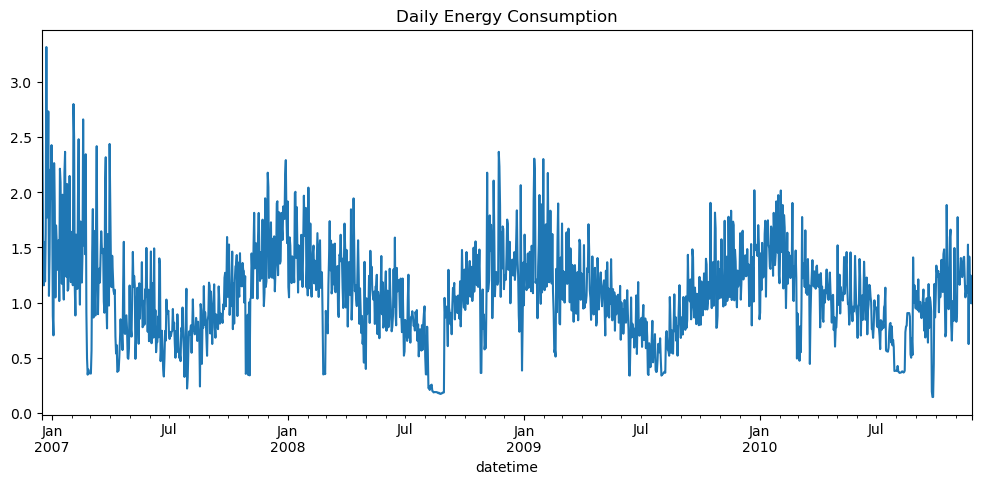

In [46]:
df_daily['Global_active_power'].plot(figsize=(12,5))
plt.title("Daily Energy Consumption")
plt.show()

## Exploratory Data Analysis (EDA)

<Axes: xlabel='datetime'>

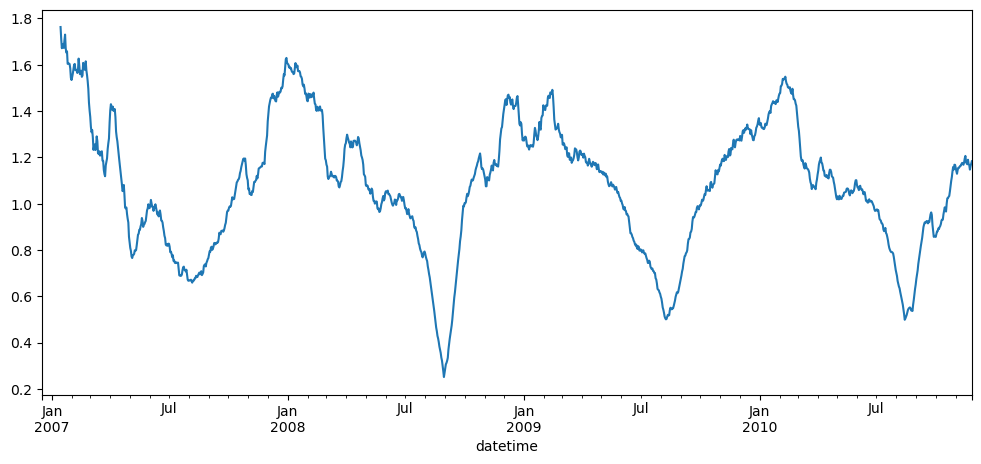

In [47]:
df_daily['Global_active_power'].rolling(window=30).mean().plot(figsize=(12,5))

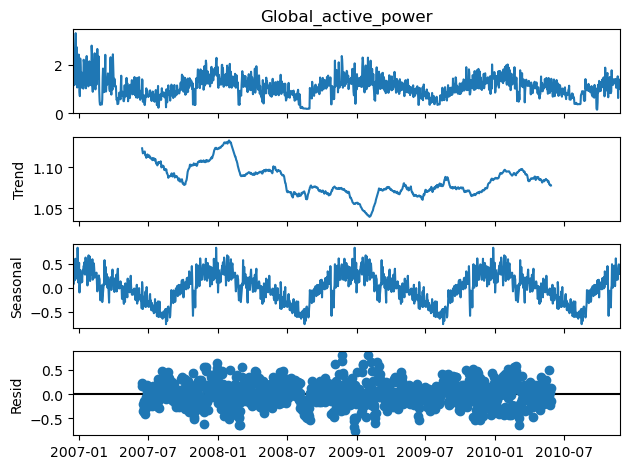

In [48]:
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(df_daily['Global_active_power'], model='additive', period=365)
result.plot()
plt.show()

<Axes: xlabel='day'>

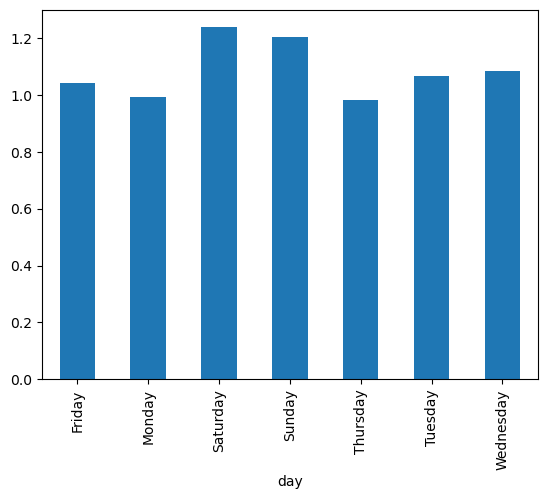

In [49]:
df_daily['day'] = df_daily.index.day_name()

df_daily.groupby('day')['Global_active_power'].mean().plot(kind='bar')

The data shows strong seasonality with recurring yearly patterns and higher energy consumption during weekends, indicating behavioral usage patterns.

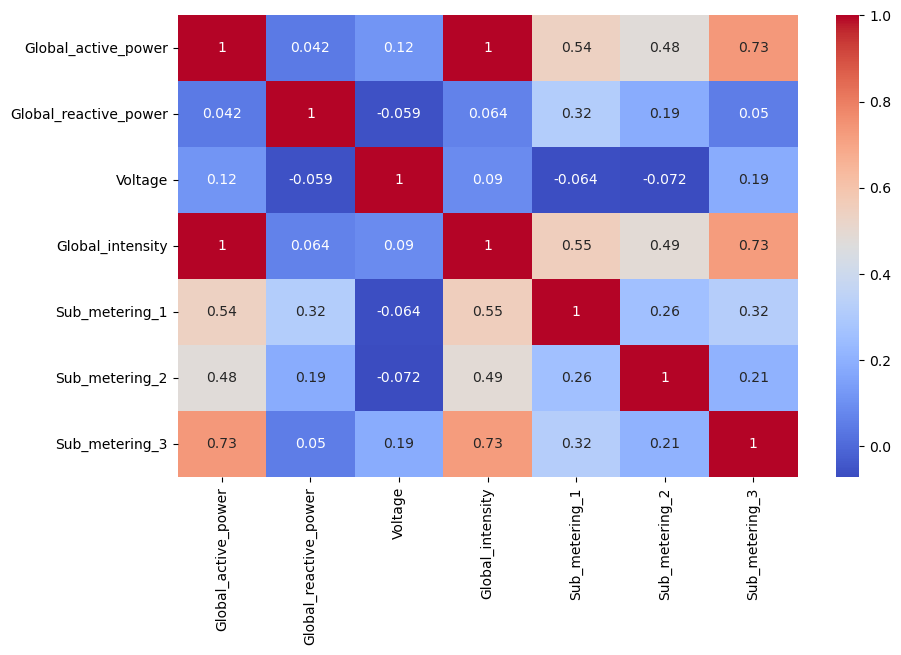

In [50]:
plt.figure(figsize=(10,6))
sns.heatmap(df_daily.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.show()

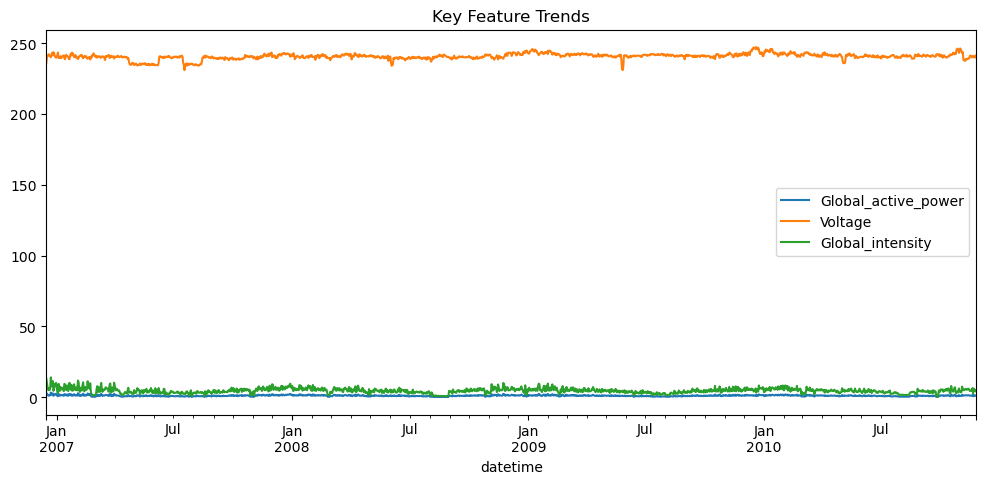

In [51]:
df_daily[['Global_active_power','Voltage','Global_intensity']].plot(figsize=(12,5))
plt.title("Key Feature Trends")
plt.show()

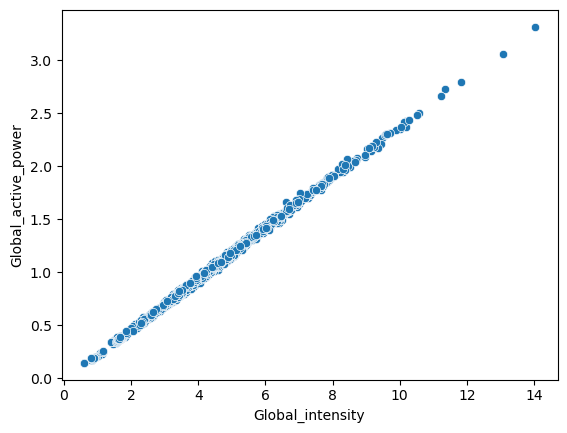

In [54]:
sns.scatterplot(x=df_daily['Global_intensity'], y=df_daily['Global_active_power'])
plt.show()

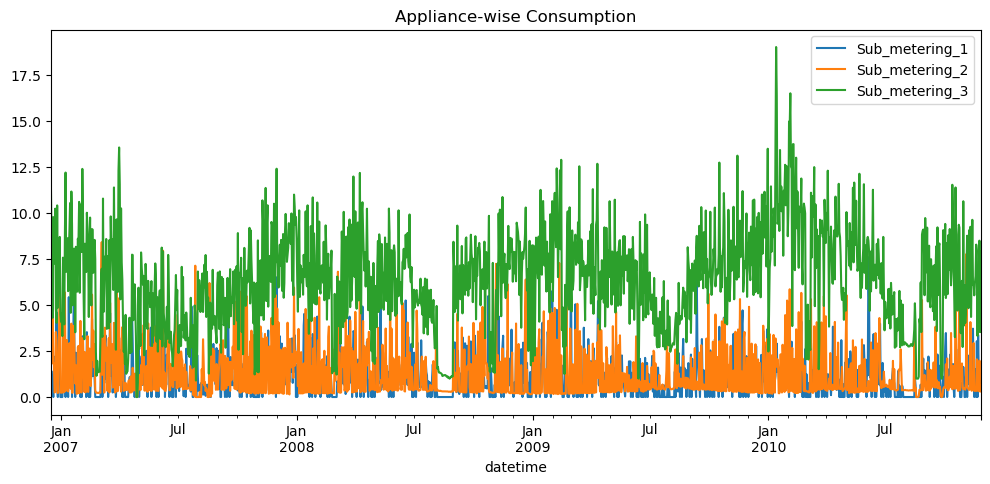

In [55]:
df_daily[['Sub_metering_1','Sub_metering_2','Sub_metering_3']].plot(figsize=(12,5))
plt.title("Appliance-wise Consumption")
plt.show()

Global_intensity shows near-perfect correlation with power consumption, while sub_metering_3 contributes significantly, indicating major appliance-driven usage patterns.

## Train-Test Split

In [56]:
train = df_daily[:-30].copy()
test = df_daily[-30:].copy()

## Feature Engineering

#### Create Lag Features
#### Rolling Features
#### Time-based Features

In [57]:
def create_features(df):
    df = df.copy()
    
    df['lag_1'] = df['Global_active_power'].shift(1)
    df['lag_7'] = df['Global_active_power'].shift(7)
    df['lag_30'] = df['Global_active_power'].shift(30)
    
    df['rolling_mean_7'] = df['Global_active_power'].shift(1).rolling(7).mean()
    df['rolling_std_7'] = df['Global_active_power'].shift(1).rolling(7).std()
    
    df['day_of_week'] = df.index.dayofweek
    df['month'] = df.index.month
    
    return df

train = create_features(train)
train = train.dropna()

# Combine last train rows to maintain continuity

In [58]:
combined = pd.concat([train.tail(30), test])

combined = create_features(combined)

test = combined.iloc[30:]
test = test.dropna()

## Preparing Data for Modeling
### Define X and y

In [59]:
features = ['lag_1','lag_7','lag_30','rolling_mean_7','rolling_std_7','day_of_week','month']

X_train = train[features]
y_train = train['Global_active_power']

X_test = test[features]
y_test = test['Global_active_power']

### Linear Regression (Baseline)

In [60]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

## Random Forest

In [61]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

## ARIMA (Time Series Model)

In [62]:
from statsmodels.tsa.arima.model import ARIMA

arima = ARIMA(train['Global_active_power'], order=(2,1,2))
arima_fit = arima.fit()

y_pred_arima = arima_fit.forecast(steps=len(test))

## SARIMA (Seasonal ARIMA)

In [63]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima = SARIMAX(
    train['Global_active_power'],
    order=(1,1,1),
    seasonal_order=(1,1,1,7),  # weekly
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima.fit(disp=False)

y_pred_sarima = sarima_fit.forecast(steps=len(test))

### Evaluation

In [64]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

## Compare All Models

In [65]:
results = {
    "Linear Regression": evaluate(y_test, y_pred_lr),
    "Random Forest": evaluate(y_test, y_pred_rf),
    "ARIMA": evaluate(y_test, y_pred_arima),
    "SARIMA": evaluate(y_test, y_pred_sarima)
}

for model, (mae, rmse) in results.items():
    print(f"{model} -> MAE: {mae:.4f}, RMSE: {rmse:.4f}")

Linear Regression -> MAE: 0.1840, RMSE: 0.2709
Random Forest -> MAE: 0.2042, RMSE: 0.2619
ARIMA -> MAE: 0.1985, RMSE: 0.2528
SARIMA -> MAE: 0.1782, RMSE: 0.2381


## Plot (All Models)

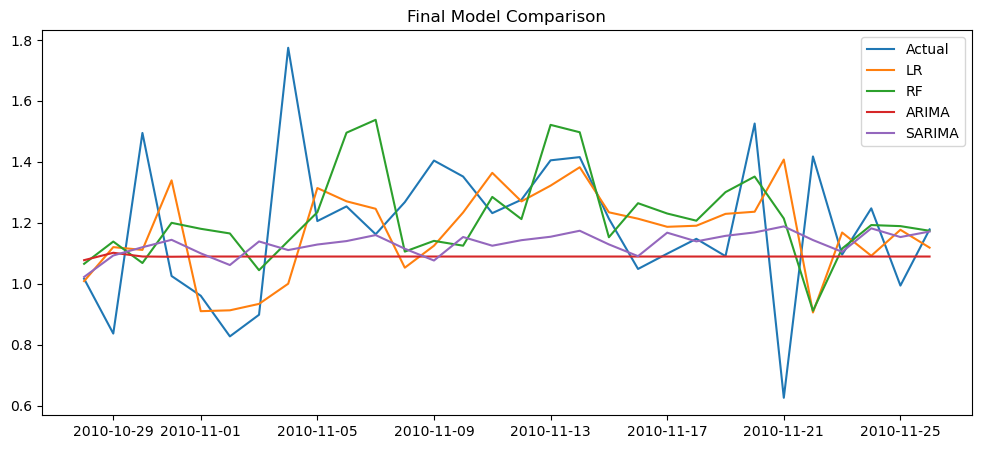

In [66]:
plt.figure(figsize=(12,5))

plt.plot(y_test.index, y_test, label='Actual')
plt.plot(y_test.index, y_pred_lr, label='LR')
plt.plot(y_test.index, y_pred_rf, label='RF')
plt.plot(y_test.index, y_pred_arima, label='ARIMA')
plt.plot(y_test.index, y_pred_sarima, label='SARIMA')

plt.legend()
plt.title("Final Model Comparison")
plt.show()

## 📊 Final Model Comparison & Selection

The performance of multiple models was evaluated using MAE and RMSE metrics, along with visual comparison of predicted vs actual values.

### 🔍 Observations:

- **Linear Regression** and **Random Forest** showed moderate performance but struggled to capture temporal patterns effectively.
- **ARIMA** produced relatively stable predictions but failed to adapt to fluctuations in the data.
- **SARIMA** demonstrated better performance by incorporating seasonality, resulting in predictions that more closely follow the actual trend.

### 📈 Metric Comparison:

| Model | MAE | RMSE |
|------|------|------|
| Linear Regression | 0.1840 | 0.2709 |
| Random Forest | 0.2042 | 0.2619 |
| ARIMA | 0.1985 | 0.2528 |
| **SARIMA** | **0.1782** | **0.2381** |

### ✅ Final Model Selection:

Based on both quantitative metrics and visual analysis, **SARIMA** was selected as the best-performing model.

### 💡 Key Insight:

Although machine learning models performed well initially, correcting data leakage revealed the true performance. Time-series models like SARIMA, which account for seasonality, proved more effective for this dataset.

### 🧠 Conclusion:

SARIMA successfully captures both trend and seasonal patterns in energy consumption data, making it the most suitable model for accurate demand forecasting in this project.